# Elaborato - Apprendimento Automatico e Apprendimento Profondo
Analisi del dataset **Car Evaluation** (UCI ML Repo).



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import shap
from ucimlrepo import fetch_ucirepo

import warnings
warnings.filterwarnings('ignore')



## 1. Acquisizione e Preprocessing dei Dati


In [2]:
# Scarichiamo il dataset
car_evaluation = fetch_ucirepo(id=19) 
X = car_evaluation.data.features 
y = car_evaluation.data.targets.values.ravel()

print("Features:\n", X.head())
print("\nTarget distribution:\n", pd.Series(y).value_counts())



Features:
   buying  maint doors persons lug_boot safety
0  vhigh  vhigh     2       2    small    low
1  vhigh  vhigh     2       2    small    med
2  vhigh  vhigh     2       2    small   high
3  vhigh  vhigh     2       2      med    low
4  vhigh  vhigh     2       2      med    med

Target distribution:
 unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [3]:
# Mappatura ordinale logica per le feature categoriche
feature_cats = [
    ['low', 'med', 'high', 'vhigh'], # buying
    ['low', 'med', 'high', 'vhigh'], # maint
    ['2', '3', '4', '5more'],        # doors
    ['2', '4', 'more'],              # persons
    ['small', 'med', 'big'],         # lug_boot
    ['low', 'med', 'high']           # safety
]
encoder = OrdinalEncoder(categories=feature_cats)
X_encoded = encoder.fit_transform(X)
X_encoded = pd.DataFrame(X_encoded, columns=X.columns)

# Mappatura manuale della variabile target per preservare l'ordinamento semantico
# unacc < acc < good < vgood
target_mapping = {'unacc': 0, 'acc': 1, 'good': 2, 'vgood': 3}
y_encoded = pd.Series(y).map(target_mapping).values
classes = np.array(['unacc', 'acc', 'good', 'vgood'])



In [4]:
# Suddivisione in Training (70%), Validation (15%), Test (15%)
# Effettuiamo PRIMA lo split per evitare Data Leakage nello StandardScaler.
X_temp, X_test, y_temp, y_test = train_test_split(X_encoded, y_encoded, test_size=0.15, random_state=42, stratify=y_encoded)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)

print(f"Dimensioni set - Train: {X_train.shape[0]}, Validation: {X_val.shape[0]}, Test: {X_test.shape[0]}")


# Standardizzazione dei dati
# Fittiamo lo scaler SOLO sul training set 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Applichiamo la stessa trasformazione al Test set
X_test_scaled = scaler.transform(X_test)



Dimensioni set - Train: 1208, Validation: 260, Test: 260


## 2. Task 1: Analisi delle Feature con PCA


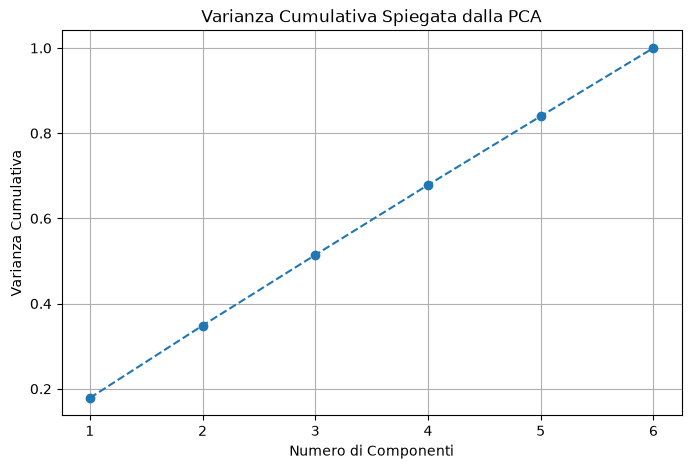

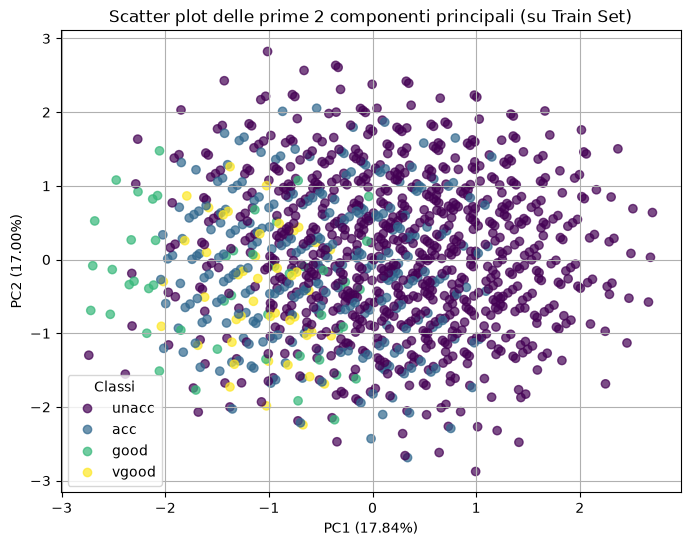

In [5]:
# Applichiamo la PCA
pca = PCA()
pca.fit(X_train_scaled)

# Plot della Varianza Spiegata
plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.title('Varianza Cumulativa Spiegata dalla PCA')
plt.xlabel('Numero di Componenti')
plt.ylabel('Varianza Cumulativa')
plt.grid(True)
plt.show()

# Trasformiamo i dati di training prendendo le prime 2 componenti per visualizzarli in 2D
pca_2d = PCA(n_components=2)
# FIT su Train per evitare data leakage visivo
X_pca_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y_train, cmap='viridis', alpha=0.7)
plt.legend(handles=scatter.legend_elements()[0], labels=list(classes), title="Classi")
plt.title('Scatter plot delle prime 2 componenti principali (su Train Set)')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True)
plt.show()



## 3. Task 2 & 3: Classificazione e Valutazione degli Algoritmi


In [6]:
# Inizializziamo i modelli
models = {
    'SVM': SVC(probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes': GaussianNB()
}

# Funzione per calcolare le metriche
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)
    
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro'),
        'Recall': recall_score(y_test, y_pred, average='macro'),
        'F1-Score': f1_score(y_test, y_pred, average='macro'),
        'ROC AUC': roc_auc_score(y_test, y_prob, multi_class='ovr')
    }
    return metrics, y_pred, y_prob

results = {}
predictions = {}
probabilities = {}

# Alleniamo e valutiamo sul test
for name, model in models.items():
    metrics, y_pred, y_prob = evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test)
    results[name] = metrics
    predictions[name] = y_pred
    probabilities[name] = y_prob

# Mostriamo le metriche a confronto
df_metrics = pd.DataFrame(results).T
display(df_metrics)



,Accuracy,Precision,Recall,F1-Score,ROC AUC
SVM,0.976923,0.944452,0.917942,0.922614,0.999100
Random Forest,0.976923,0.927506,0.915006,0.916773,0.999204
Naive Bayes,0.692308,0.406776,0.512884,0.362945,0.888925


## 4. Task 4: Matrici di Confusione e Curve ROC


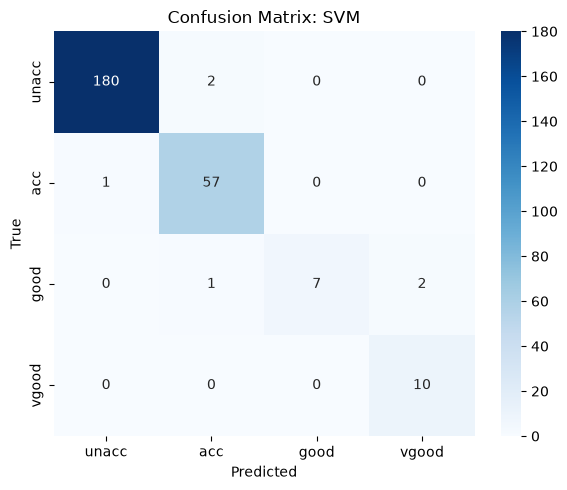

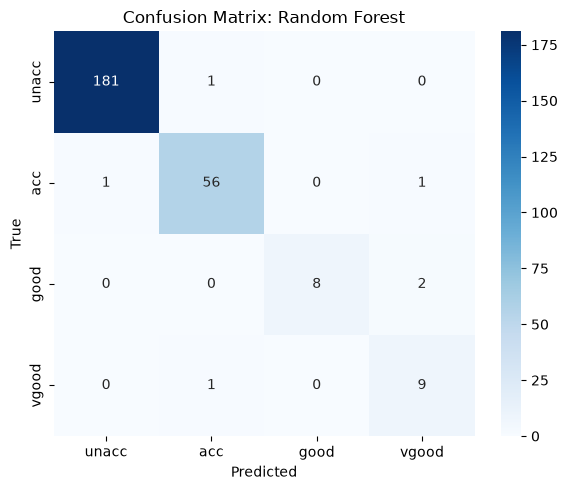

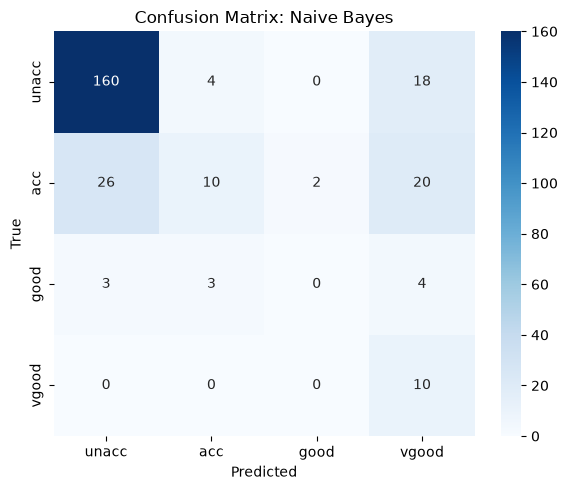

In [7]:
# 1. Confusion Matrix
for name, y_pred in predictions.items():
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_test, y_pred)
    # Custom encoding, le classi seguono l'ordine semantico corretto!
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()



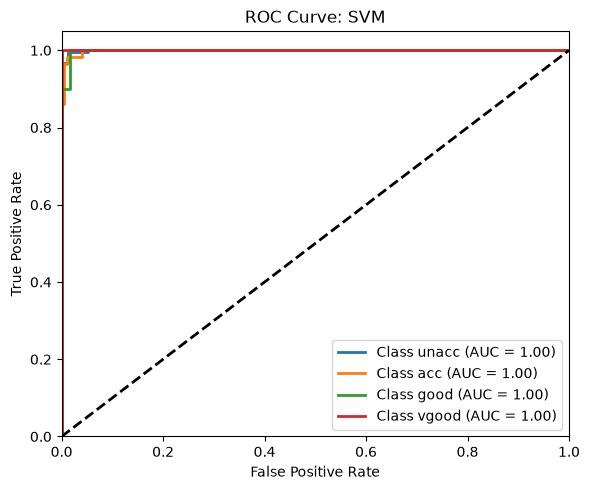

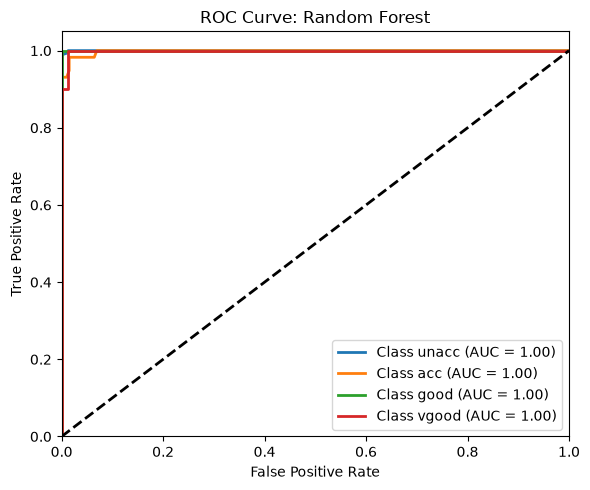

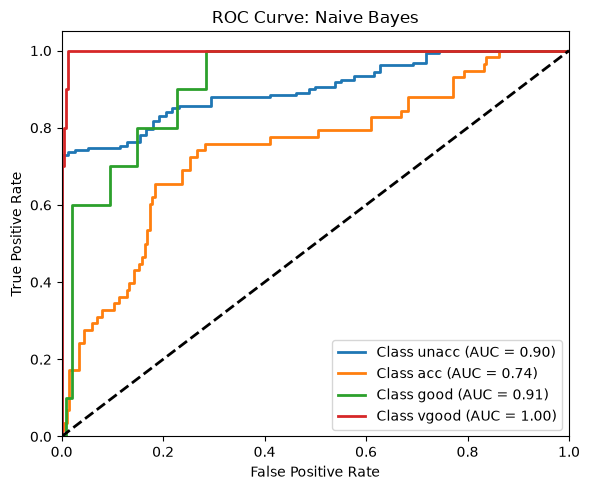

In [8]:
# 2. ROC Curve
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
n_classes = y_test_bin.shape[1]

for name, y_prob in probabilities.items():
    plt.figure(figsize=(6, 5))
    for j in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, j], y_prob[:, j])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'Class {classes[j]} (AUC = {roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve: {name}')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()



## 5. Task 5: Explainable AI con SHAP


Summary Plot (Feature Importance) per la classe: unacc


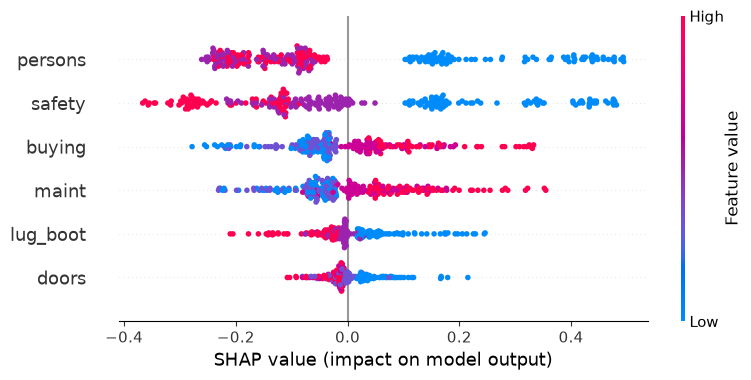

Summary Plot globale multi-classe (Bar chart)


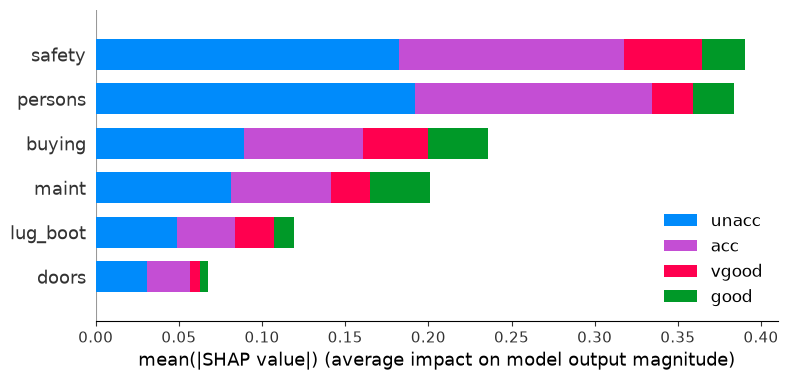

In [9]:
# Prendiamo il modello Random Forest addestrato
rf_model = models['Random Forest']

# Creiamo l'Explainer SHAP per alberi decisionali
explainer = shap.TreeExplainer(rf_model)
# Calcoliamo i valori SHAP per il test set
shap_values = explainer.shap_values(X_test_scaled)

class_idx = list(classes).index('unacc')
print(f"Summary Plot (Feature Importance) per la classe: {classes[class_idx]}")

# Conversion per plot multiclasse
if isinstance(shap_values, list):
    shap_values_list = shap_values
else:
    shap_values_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

shap.summary_plot(shap_values_list[class_idx], X_test_scaled, feature_names=X.columns)

print(f"Summary Plot globale multi-classe (Bar chart)")
shap.summary_plot(shap_values_list, X_test_scaled, feature_names=X.columns, class_names=classes, plot_type='bar')

